In [1]:
!pip install -q -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 8.7 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import json
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import ultralytics
import yaml
from collections import Counter
from tqdm.auto import tqdm

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [4]:
DATASET_ROOT = Path("/content/datasets")

DATA_YAML_PATH = Path("/content/drive/MyDrive/vision_unit_02_outputs/block_02/crack_seg_local.yaml")

OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/"
    "vision_unit_02_outputs/"
    "block_04"
)

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
RUN_NAME = "yolo26n_crack_seg_v1"
RUN_DIRECTORY = OUTPUT_ROOT / RUN_NAME


BEST_MODEL_PATH = (
    RUN_DIRECTORY
    / "weights"
    / "best.pt"
)

LAST_MODEL_PATH = (
    RUN_DIRECTORY
    / "weights"
    / "last.pt"
)

print("Dataset YAML:", DATA_YAML_PATH)
print("Output:", OUTPUT_ROOT)

Dataset YAML: /content/drive/MyDrive/vision_unit_02_outputs/block_02/crack_seg_local.yaml
Output: /content/drive/MyDrive/vision_unit_02_outputs/block_04


**Training-aligned validation**

In [5]:
best_model = YOLO(str(BEST_MODEL_PATH))

aligned_metrics = best_model.val(
    data=str(DATA_YAML_PATH),
    split="val",
    imgsz=416,
    batch=16,
    device=0,
    workers=2,

    rect=False,
    nms=True,

    mask_ratio=2,
    overlap_mask=False,

    save_json=False,
    save_txt=False,
    plots=True,

    project=str(OUTPUT_ROOT),
    name="aligned_validation",
    exist_ok=True,
)

Ultralytics 8.4.149 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-seg summary (fused): 136 layers, 2,689,079 parameters, 0 gradients, 9.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 676.2±242.3 MB/s, size: 20.6 KB)
val: Scanning /content/datasets/labels/val... 200 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 978.0it/s 0.2s0.0s
val: New cache created: /content/datasets/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.7it/s 4.9s0.1s
                   all        200        249      0.837      0.679      0.795      0.617      0.671      0.538      0.535      0.182
Speed: 0.9ms preprocess, 5.2ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to /content/drive/MyDrive/vision_unit_02_outputs/block_04/aligned_validation


In [ ]:
aligned_metric_report = {
    "box_precision": float(aligned_metrics.box.mp),
    "box_recall": float(aligned_metrics.box.mr),
    
    "box_map50": float(aligned_metrics.box.map50),
    "box_map75": float(aligned_metrics.box.map75),
    "box_map50_95": float(aligned_metrics.box.map),

    "mask_precision": float(aligned_metrics.seg.mp),
    "mask_recall": float(aligned_metrics.seg.mr),
    
    "mask_map50": float(aligned_metrics.seg.map50),
    "mask_map75": float(aligned_metrics.seg.map75),
    "mask_map50_95": float(aligned_metrics.seg.map),

    "speed_ms": {
        key: float(value)
        for key, value
        in aligned_metrics.speed.items()
    },

    "mask_ratio": 2,
    "overlap_mask": False,
    "test_split_used": False,
}

In [7]:
aligned_report_path = (
    OUTPUT_ROOT
    / "aligned_validation_metrics.json"
)

aligned_report_path.write_text(
    json.dumps(aligned_metric_report,indent=2), encoding="utf-8"
)

print(json.dumps(aligned_metric_report, indent=2))

{
  "box_precision": 0.8374692391604532,
  "box_recall": 0.678714859437751,
  "box_map50": 0.7949510780869888,
  "box_map75": 0.6834100119805757,
  "box_map50_95": 0.6169979657437055,
  "mask_precision": 0.6714270553679451,
  "mask_recall": 0.5381526104417671,
  "mask_map50": 0.5345878814850461,
  "mask_map75": 0.04659083292983961,
  "mask_map50_95": 0.18194126395631618,
  "speed_ms": {
    "preprocess": 0.9070706349996271,
    "inference": 5.224592254999152,
    "loss": 0.0009394399995699132,
    "postprocess": 3.375035860000253
  },
  "mask_ratio": 2,
  "overlap_mask": false,
  "test_split_used": false
}


### Confidence behavior and instance matching

In [8]:
VALIDATION_IMAGE_DIRECTORY = DATASET_ROOT / "images" / "val"
VALIDATION_LABEL_DIRECTORY = DATASET_ROOT / "labels" / "val"

ANALYSIS_MIN_CONFIDENCE = 0.01
MATCH_MASK_IOU = 0.50
LOCALIZATION_IOU_FLOOR = 0.10

**Load ground-truth instance masks**

In [9]:
def load_ground_truth_masks(image_path):
    image_path = Path(image_path)
    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    
    if image is None:
        raise FileNotFoundError(image_path)

    height, width = image.shape[:2]
    label_path = (VALIDATION_LABEL_DIRECTORY / f"{image_path.stem}.txt")
    
    masks = []
    if label_path.is_file():
        lines = label_path.read_text(encoding="utf-8").splitlines()
        
        for line in lines:
            line = line.strip()
            if not line:
                continue
            
            values = [float(value) for value in line.split()]
            class_id = int(values[0])
            
            coordinates = np.array(values[1:], dtype=np.float32).reshape(-1, 2)
            
            pixel_points = (
                coordinates * np.array([width, height], dtype=np.float32)
            )
            
            pixel_points[:, 0] = (
                np.clip(pixel_points[:, 0], 0, width - 1)
            )
            pixel_points[:, 1] = (
                np.clip(pixel_points[:, 1], 0, height - 1)
            )
            
            pixel_points = np.rint(pixel_points).astype(np.int32)
            instance_mask = np.zeros((height, width), dtype=np.uint8)
            
            cv2.fillPoly(instance_mask, [pixel_points], color=1)
            masks.append(instance_mask)
    
    if not masks:
        return np.zeros((0, height, width), dtype=np.uint8)

    return np.stack(masks, axis=0)

**Extract predicted masks**

In [ ]:
def extract_prediction_arrays(result):
    height, width = result.orig_shape
    
    if (result.masks is None or len(result.boxes) == 0):
        return {
            "confidences": np.zeros(0, dtype=np.float32),
            "boxes": np.zeros((0, 4), dtype=np.float32),
            "masks": np.zeros((0, height, width), dtype=np.uint8),
        }
    
    confidences = result.boxes.conf.detach().cpu().numpy().astype(np.float32)
    
    boxes = result.boxes.xyxy.detach().cpu().numpy().astype(np.float32)

    masks = result.masks.data.detach().cpu().numpy()
    masks = (masks >= 0.50).astype(np.uint8)
    
    if masks.shape[1:] != (height, width):
        masks = np.stack([
            cv2.resize(
                mask, (width, height),
                interpolation=cv2.INTER_NEAREST
            ) for mask in masks
        ], axis=0)
        
    
    return {
        "confidences": confidences,
        "boxes": boxes,
        "masks": masks,
    }

**Mask IoU matrix**

In [11]:
def calculate_mask_iou_matrix(prediction_masks, ground_truth_masks):
    prediction_count = len(prediction_masks)
    ground_truth_count = len(ground_truth_masks)
    
    iou_matrix = np.zeros(
        (prediction_count, ground_truth_count), dtype=np.float32
    )
    
    for prediction_index in range(prediction_count):
        prediction = prediction_masks[prediction_index].astype(bool)
        
        for gt_index in range(ground_truth_count):
            ground_truth =ground_truth_masks[gt_index].astype(bool)
            
            intersection = np.logical_and(prediction, ground_truth).sum()
            
            union = np.logical_or(prediction, ground_truth).sum()
            
            iou_matrix[prediction_index, gt_index] = (intersection / union if union > 0 else 0.0)
            
    return iou_matrix

**Run validation inference once**

In [12]:
analysis_cache = []

prediction_generator = best_model.predict(
    source=str(VALIDATION_IMAGE_DIRECTORY),
    stream=True,
    
    imgsz=416,
    conf=ANALYSIS_MIN_CONFIDENCE,
    iou=0.70,
    nms=True,
    
    retina_masks=True,
    rect=False,
    max_det=300,

    device=0,
    verbose=False
)

for result in tqdm(prediction_generator, total=200):
    prediction_data = extract_prediction_arrays(result)
    
    ground_truth_masks = load_ground_truth_masks(result.path)
    
    iou_matrix = calculate_mask_iou_matrix(prediction_data["masks"], ground_truth_masks)
    
    analysis_cache.append({
        "image_path": str(result.path),
        "confidences": prediction_data["confidences"],
        "boxes":prediction_data["boxes"],
        "iou_matrix": iou_matrix,
        "gt_count": len(ground_truth_masks),
        "prediction_count": len(prediction_data["masks"])
    })

print("Images cached:", len(analysis_cache))
print(
    "Low-confidence predictions:",
    sum(item["prediction_count"] for item in analysis_cache),
)
print(
    "Ground-truth instances:",
    sum(item["gt_count"] for item in analysis_cache),
)

  0%|          | 0/200 [00:00<?, ?it/s]

Images cached: 200
Low-confidence predictions: 1865
Ground-truth instances: 249


**One-to-one matching**

In [13]:
def match_instances(confidences, iou_matrix, ground_truth_count, confidence_threshold, match_iou=0.50):
    
    selected_indices = np.flatnonzero(confidences >= confidence_threshold)
    
    selected_indices = sorted(
        selected_indices.tolist(),
        key=lambda index: (-float(confidences[index]))
    )
    
    available_ground_truths = set(range(ground_truth_count))
    
    matches = []
    unmatched_predictions = []
    
    for prediction_index in (selected_indices):
        if not available_ground_truths:
            unmatched_predictions.append(prediction_index)
            continue
        
        best_gt_index = max(
            available_ground_truths,
            key=lambda gt_index: float(
                iou_matrix[prediction_index, gt_index]
            )
        )
        best_iou = float(
            iou_matrix[prediction_index, best_gt_index]
        )
        
        if best_iou >= match_iou:
            matches.append({
                "prediction_index": prediction_index,
                "gt_index": best_gt_index,
                "mask_iou": best_iou
            })
            
            available_ground_truths.remove(best_gt_index)
        else:
            unmatched_predictions.append(prediction_index)
            
    return {
        "selected_indices": selected_indices,
        "matches": matches,
        "unmatched_predictions": unmatched_predictions,
        "unmatched_ground_truths": sorted(available_ground_truths),
    }

**Confidence-threshold sweep**

In [14]:
CONFIDENCE_THRESHOLDS = np.round(np.arange(0.05, 0.91, 0.05), 2)

threshold_rows = []

for confidence_threshold in (CONFIDENCE_THRESHOLDS):
    total_tp = 0
    total_fp = 0
    total_fn = 0
    total_predictions = 0
    
    for item in analysis_cache:
        matching = match_instances(
            confidences=item["confidences"],
            iou_matrix=item["iou_matrix"],
            ground_truth_count=item["gt_count"],
            confidence_threshold = float(confidence_threshold),
            match_iou = MATCH_MASK_IOU
        )
    
        tp = len(matching["matches"])
        fp = len(matching["unmatched_predictions"])
        fn = len(matching["unmatched_ground_truths"])
        
        total_tp += tp
        total_fp += fp
        total_fn += fn
        
        total_predictions += len(matching["selected_indices"])
        
    
    precision = (
        total_tp / (total_tp + total_fp)
        if total_tp + total_fp > 0 else 0.0
    )

    recall = (
        total_tp / (total_tp + total_fn)
        if total_tp + total_fn > 0 else 0.0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0 else 0.0
    )

    threshold_rows.append(
        {
            "confidence_threshold": float(confidence_threshold),
            "tp": total_tp,
            "fp": total_fp,
            "fn": total_fn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "predictions_per_image": (
                total_predictions / len(analysis_cache)
            ),
        }
    )

In [15]:
confidence_sweep = pd.DataFrame(threshold_rows)

best_threshold_index = (confidence_sweep["f1"].idxmax())

best_operating_row = (confidence_sweep.loc[best_threshold_index])

BEST_CONFIDENCE_THRESHOLD = float(best_operating_row[ "confidence_threshold"])

confidence_sweep_path = OUTPUT_ROOT / "instance_confidence_sweep.csv"

confidence_sweep.to_csv(confidence_sweep_path, index=False)

display(confidence_sweep)

,confidence_threshold,tp,fp,fn,precision,recall,f1,predictions_per_image
0,0.05,182,442,67,0.291667,0.730924,0.416953,3.120
1,0.10,179,251,70,0.416279,0.718876,0.527246,2.150
2,0.15,176,172,73,0.505747,0.706827,0.589615,1.740
3,0.20,173,135,76,0.561688,0.694779,0.621185,1.540
4,0.25,165,114,84,0.591398,0.662651,0.625000,1.395
5,0.30,161,91,88,0.638889,0.646586,0.642715,1.260
6,0.35,152,77,97,0.663755,0.610442,0.635983,1.145
7,0.40,148,65,101,0.694836,0.594378,0.640693,1.065
8,0.45,145,58,104,0.714286,0.582329,0.641593,1.015
9,0.50,144,50,105,0.742268,0.578313,0.650113,0.970


**Confidence behavior plot**

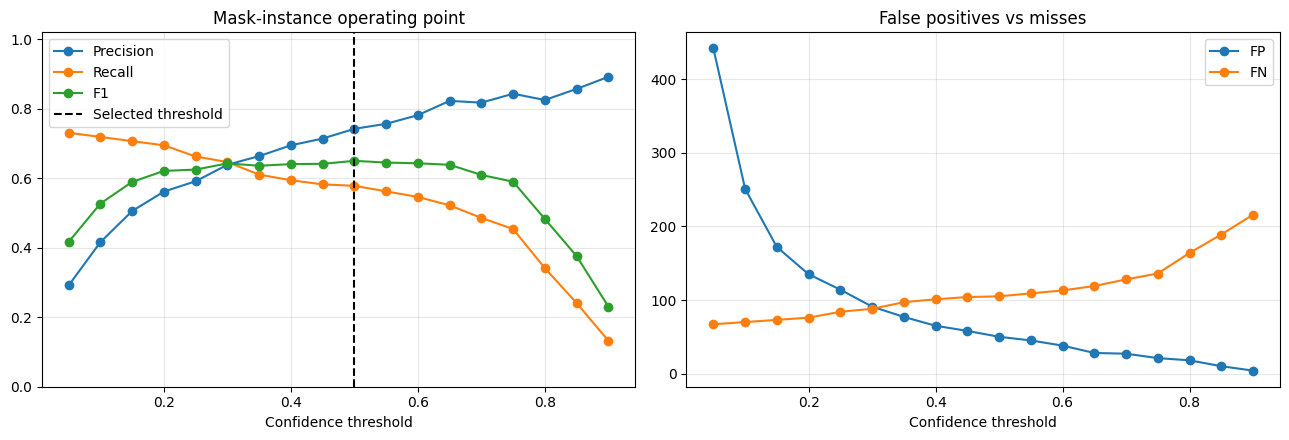

In [16]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(
    confidence_sweep["confidence_threshold"],
    confidence_sweep["precision"],
    marker="o",
    label="Precision",
)
axes[0].plot(
    confidence_sweep["confidence_threshold"],
    confidence_sweep["recall"],
    marker="o",
    label="Recall",
)
axes[0].plot(
    confidence_sweep["confidence_threshold"],
    confidence_sweep["f1"],
    marker="o",
    label="F1",
)
axes[0].axvline(
    BEST_CONFIDENCE_THRESHOLD,
    color="black",
    linestyle="--",
    label="Selected threshold",
)
axes[0].set_title("Mask-instance operating point")
axes[0].set_xlabel("Confidence threshold")
axes[0].set_ylim(0.0, 1.02)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    confidence_sweep["confidence_threshold"],
    confidence_sweep["fp"],
    marker="o",
    label="FP",
)
axes[1].plot(
    confidence_sweep["confidence_threshold"],
    confidence_sweep["fn"],
    marker="o",
    label="FN",
)
axes[1].set_title("False positives vs misses")
axes[1].set_xlabel("Confidence threshold")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()

confidence_figure_path = OUTPUT_ROOT / "instance_confidence_behavior.png"
plt.savefig(
    confidence_figure_path,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

### Duplicate and missed-instance analysis

**Failure reason helper**

In [38]:
def classify_unmatched_prediction(prediction_index, iou_matrix):
    if iou_matrix.shape[1] == 0:
        return {
            "reason": "background_fp",
            "best_gt_index": None,
            "maximum_mask_iou": 0.0,
        }

    best_gt_index = int(np.argmax(iou_matrix[prediction_index]))
    maximum_mask_iou = float(iou_matrix[prediction_index, best_gt_index])

    if maximum_mask_iou >= MATCH_MASK_IOU:
        reason = "duplicate"

    elif maximum_mask_iou >= LOCALIZATION_IOU_FLOOR:
        reason = "poor_localization"

    else:
        reason = "background_fp"

    return {
        "reason": reason,
        "best_gt_index": best_gt_index,
        "maximum_mask_iou": maximum_mask_iou,
    }

**Generate detailed failure tables**

In [39]:
failure_reason_counts = Counter()

per_image_rows = []
prediction_detail_rows = []
missed_ground_truth_rows = []

for item in analysis_cache:
    matching = match_instances(
        confidences=item["confidences"],
        iou_matrix=item["iou_matrix"],
        ground_truth_count=item["gt_count"],
        confidence_threshold=BEST_CONFIDENCE_THRESHOLD,
        match_iou=MATCH_MASK_IOU,
    )

    matched_by_prediction = {
        match["prediction_index"]: match
        for match in matching["matches"]
    }

    duplicate_count = 0
    poor_localization_count = 0
    background_fp_count = 0

    for prediction_index in matching["selected_indices"]:
        confidence = float(
            item["confidences"][prediction_index]
        )

        if prediction_index in matched_by_prediction:
            match = matched_by_prediction[prediction_index]

            prediction_detail_rows.append({
                "image": Path(item["image_path"]).name,
                "prediction_index": prediction_index,
                "confidence": confidence,
                "status": "TP",
                "reason": "matched",
                "matched_gt_index": match["gt_index"],
                "maximum_mask_iou": match["mask_iou"]
            })

        else:
            failure = classify_unmatched_prediction(
                prediction_index, item["iou_matrix"]
            )

            reason = failure["reason"]
            failure_reason_counts[reason] += 1

            if reason == "duplicate":
                duplicate_count += 1
            elif reason == "poor_localization":
                poor_localization_count += 1
            else:
                background_fp_count += 1

            prediction_detail_rows.append({
                "image": Path(item["image_path"]).name,
                "prediction_index": prediction_index,
                "confidence": confidence,
                "status": "FP",
                "reason": reason,
                "matched_gt_index": failure["best_gt_index"],
                "maximum_mask_iou": failure["maximum_mask_iou"]
            })

    for gt_index in matching["unmatched_ground_truths"]:
        missed_ground_truth_rows.append({
            "image": Path(item["image_path"]).name,
            "gt_index": gt_index,
            "reason": "missed_instance"
        })

    tp = len(matching["matches"])
    fp = len(matching["unmatched_predictions"])
    fn = len(matching["unmatched_ground_truths"])

    per_image_rows.append({
        "image": Path(item["image_path"]).name,
        "gt_instances": item["gt_count"],
        "predicted_instances": len(matching["selected_indices"]),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "duplicates": duplicate_count,
        "poor_localization": poor_localization_count,
        "background_fp": background_fp_count,
        "total_errors": fp + fn
    })

print("Cached images:", len(analysis_cache))
print("Per-image rows:", len(per_image_rows))
print("Missed instances:", len(missed_ground_truth_rows))

assert len(per_image_rows) == len(analysis_cache)

Cached images: 200
Per-image rows: 200
Missed instances: 105


In [40]:
per_image_errors = pd.DataFrame(per_image_rows)
prediction_details = pd.DataFrame( prediction_detail_rows)
missed_ground_truths = pd.DataFrame(missed_ground_truth_rows)

failure_summary = pd.DataFrame(
    [
        {
            "category": category,
            "count": count,
        }
        for category, count in failure_reason_counts.items()
    ]
).sort_values("count", ascending=False)

In [41]:
per_image_errors.to_csv(
OUTPUT_ROOT
    / "per_image_instance_errors.csv",
    index=False,
)

prediction_details.to_csv(
    OUTPUT_ROOT
    / "prediction_failure_details.csv",
    index=False,
)

missed_ground_truths.to_csv(
    OUTPUT_ROOT
    / "missed_ground_truths.csv",
    index=False,
)

failure_summary.to_csv(
    OUTPUT_ROOT
    / "failure_categories.csv",
    index=False,
)

display(failure_summary)
print("Missed GT instances:", len(missed_ground_truths),)

,category,count
0,poor_localization,43
1,background_fp,6
2,duplicate,1


Missed GT instances: 105


**High-confidence failures**

In [43]:
high_confidence_failures = prediction_details[
    (prediction_details["status"] == "FP") & (prediction_details["confidence"] >= 0.70)
].sort_values("confidence", ascending=False)

print("High-confidence FP:",len(high_confidence_failures))
display(high_confidence_failures.head(20))

high_confidence_failures.to_csv(
    OUTPUT_ROOT
    / "high_confidence_failures.csv",
    index=False,
)

High-confidence FP: 27


,image,prediction_index,confidence,status,reason,matched_gt_index,maximum_mask_iou
155,3393.rf.6e2984dcac5c6bff33ae47399b7f6baf.jpg,0,0.919052,FP,poor_localization,0.0,0.290241
129,3195.rf.e3ae0cd9816c8c0601044343d91cbc09.jpg,0,0.910871,FP,poor_localization,0.0,0.134078
99,2564.rf.a3a856931be83adb4b07527ea61f1af3.jpg,0,0.909533,FP,poor_localization,0.0,0.488779
75,2345.rf.d6bde0b8adb5c07dd004c1c183925027.jpg,0,0.908726,FP,poor_localization,1.0,0.195821
117,3076.rf.d118523f1ee4758f16cccda36708c02b.jpg,0,0.893881,FP,poor_localization,0.0,0.454177
58,2181.rf.6337583054f0b69e67577f0b1aca1d49.jpg,0,0.890789,FP,poor_localization,0.0,0.364470
11,1699.rf.c2735c330999d4f748d626678163e43d.jpg,0,0.886585,FP,poor_localization,0.0,0.431710
74,2322.rf.31dc73dfcd176c28e92a57f95b95bcef.jpg,0,0.873084,FP,poor_localization,0.0,0.405569
71,2301.rf.69d6956e46333d6addfe66437376e0a8.jpg,0,0.859003,FP,poor_localization,0.0,0.463834
62,2218.rf.20b52d29fb68b8cac84cb1d61206f101.jpg,0,0.854053,FP,poor_localization,0.0,0.398954


### Failure visualization

**Select FP-heavy and FN-heavy images**

In [44]:
fp_heavy_image = per_image_errors.sort_values([
  "duplicates", "fp", "total_errors"  
], ascending=False).head(4)["image"].tolist()


fn_heavy_image = per_image_errors.sort_values([
   "fn", "total_errors"  
], ascending=False).head(4)["image"].tolist()

failure_images = list(
    dict.fromkeys(fp_heavy_image + fn_heavy_image)
)

if len(failure_images) < 8:
    additional_image = per_image_errors.sort_values(
    "total_errors",ascending=False)["image"].tolist()
    
    for image_name in additional_image:
        if image_name not in failure_images:
            failure_images.append(image_name)
        
        if len(failure_images) == 8:
            break


failure_images = failure_images[:8]
print(failure_images)

['2136.rf.8f690575dde3531db2c7850f93b62f0d.jpg', '3230.rf.cdf99c85e1872477118a3b6537bbdff8.jpg', '1923.rf.b8291b9800a23b33cb233fcf8a792f9b.jpg', '2537.rf.8d6b4c731839518a75f5a8b6f937a424.jpg', '2352.rf.13d894635b7d1c9765f6d1a2404156b7.jpg', '3393.rf.6e2984dcac5c6bff33ae47399b7f6baf.jpg', '1971.rf.d029ad8edf2ff5e40a416a1399e143ae.jpg', '1629.rf.3ecf969381ffe53960ebb20a47013488.jpg']


**Draw categorized predictions**

In [45]:
FAILURE_COLORS = {
    "TP": np.array(
        [0, 180, 255],
        dtype=np.float32,
    ),
    "duplicate": np.array(
        [255, 0, 255],
        dtype=np.float32,
    ),
    "poor_localization": np.array(
        [255, 140, 0],
        dtype=np.float32,
    ),
    "background_fp": np.array(
        [255, 0, 0],
        dtype=np.float32,
    ),
}

In [46]:
def overlay_mask(image, mask, color, alpha=0.45):
    output = image.copy()
    selected = mask.astype(bool)
    
    output[selected] = (
        (1.0 - alpha) * output[selected] + alpha * color
    )
    
    return output

In [47]:
def draw_failure_result(result):
    original_rgb = cv2.cvtColor(
        result.orig_img, cv2.COLOR_BGR2RGB
    )
    
    prediction_data = extract_prediction_arrays(result)
    ground_truth_masks = load_ground_truth_masks(result.path)
    
    iou_matrix = calculate_mask_iou_matrix(prediction_data["masks"], ground_truth_masks)
    
    matching = match_instances(
        confidences=prediction_data["confidences"],
        iou_matrix=iou_matrix,
        ground_truth_count=len( ground_truth_masks),
        confidence_threshold=BEST_CONFIDENCE_THRESHOLD,
        match_iou=MATCH_MASK_IOU,
    )

    matched_by_prediction = {
        item["prediction_index"]: item
        for item in matching["matches"]
    }

    matched_gt_indices = {
        item["gt_index"] for item in matching["matches"]
    }

    canvas = original_rgb.copy()
    
    for prediction_index in matching["selected_indices"]:
        if prediction_index in matched_by_prediction:
            status = "TP"
        else:
            status = classify_unmatched_prediction(
                prediction_index, iou_matrix,
            )["reason"]

        color = FAILURE_COLORS[status]
        canvas = overlay_mask(
            canvas,
            prediction_data["masks"][prediction_index],
            color,
        )
        
        x1, y1, x2, y2 = (
            prediction_data["boxes"][prediction_index].astype(int)
        )

        confidence =prediction_data["confidences"][prediction_index]
        
        cv2.rectangle(
            canvas,
            (x1, y1), (x2, y2),
            tuple(int(value) for value in color), 1
        )

        cv2.putText(
            canvas,
            (
                f"{status} "
                f"{confidence:.2f}"
            ),
            (
                max(0, x1), max(12, y1 - 4),
            ),
            cv2.FONT_HERSHEY_SIMPLEX, 0.35,
            tuple(int(value) for value in color),
            1, cv2.LINE_AA,
        )

    for gt_index, gt_mask in enumerate(ground_truth_masks):
        contours, _ = cv2.findContours(
            gt_mask.astype(np.uint8),
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE,
        )

        if gt_index in matched_gt_indices:
            contour_color = (0, 255, 0)
            thickness = 1

        else:
            contour_color = (255, 255, 0)
            thickness = 3

        cv2.drawContours(
            canvas,
            contours,
            contourIdx=-1,
            color=contour_color,
            thickness=thickness,
        )

    return (
        np.clip(canvas, 0, 255).astype(np.uint8),
        matching
    )

**Generate failure grid**

In [48]:
failure_image_paths = [
    str(VALIDATION_IMAGE_DIRECTORY / image_name) for image_name in failure_images
]

failure_results = best_model.predict(
    source=failure_image_paths,
    
    imgsz=416,
    conf=BEST_CONFIDENCE_THRESHOLD,
    iou=0.70,
    nms=True,
    
    retina_masks=True,
    rect=False,

    device=0,
    verbose=False
)

In [49]:
print(f"Total failure images selected: {len(failure_images)}")
print(failure_images)

Total failure images selected: 8
['2136.rf.8f690575dde3531db2c7850f93b62f0d.jpg', '3230.rf.cdf99c85e1872477118a3b6537bbdff8.jpg', '1923.rf.b8291b9800a23b33cb233fcf8a792f9b.jpg', '2537.rf.8d6b4c731839518a75f5a8b6f937a424.jpg', '2352.rf.13d894635b7d1c9765f6d1a2404156b7.jpg', '3393.rf.6e2984dcac5c6bff33ae47399b7f6baf.jpg', '1971.rf.d029ad8edf2ff5e40a416a1399e143ae.jpg', '1629.rf.3ecf969381ffe53960ebb20a47013488.jpg']


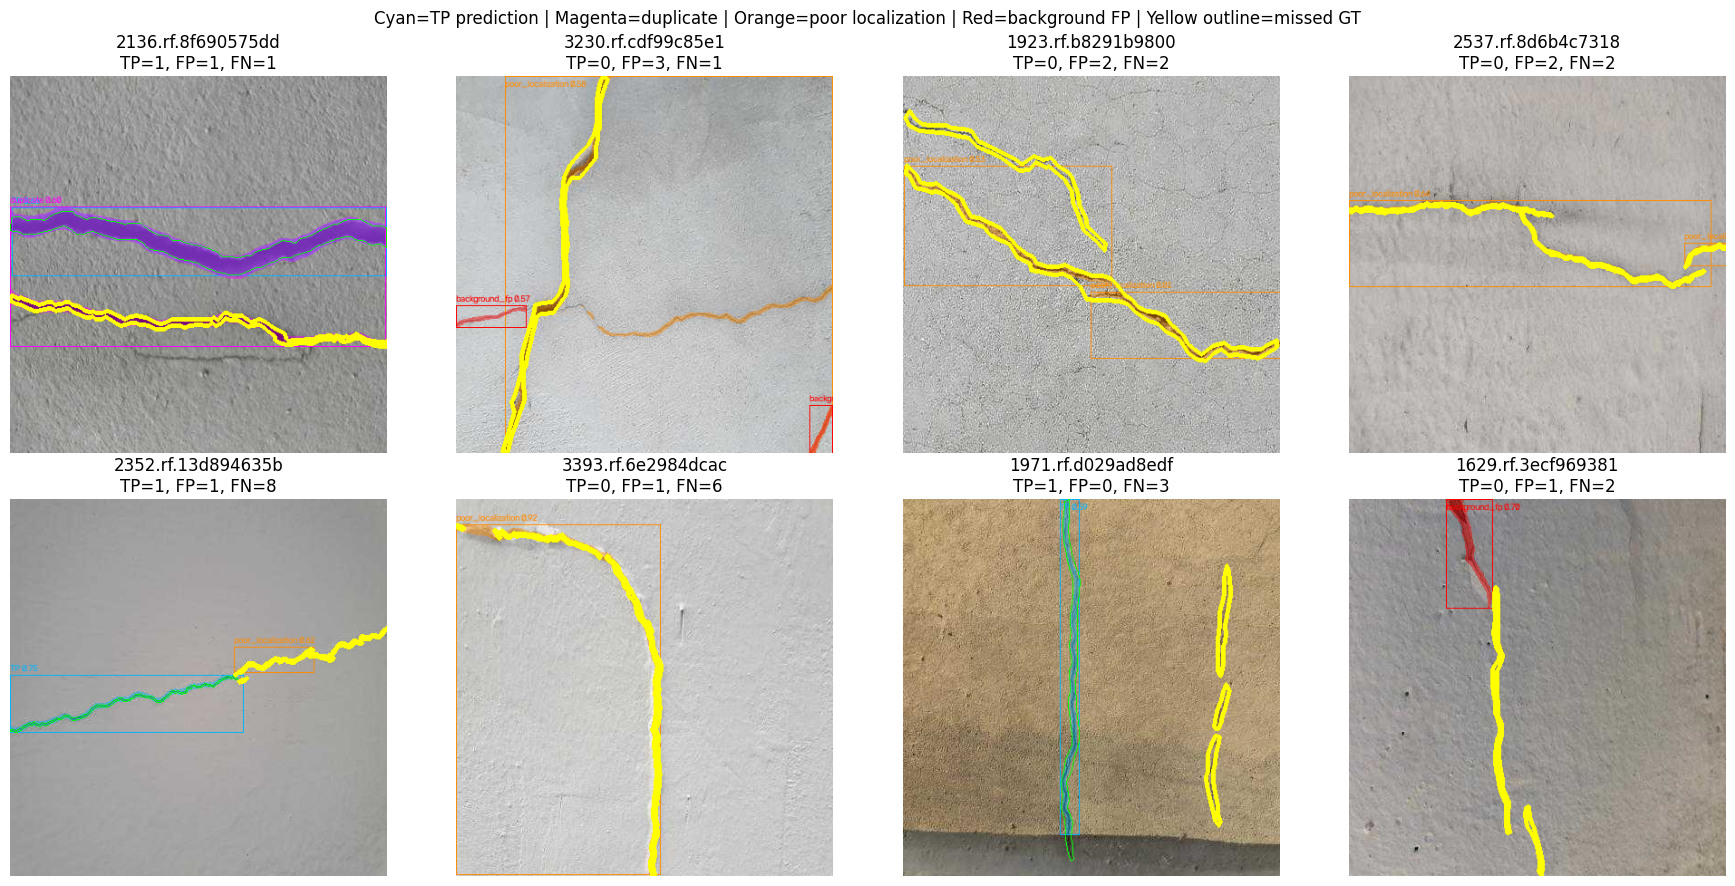

In [50]:
figure, axes = plt.subplots(2, 4, figsize=(18, 9))

for axis, result in zip(axes.flat, failure_results):
    visualization, matching = draw_failure_result(result)

    tp = len(matching["matches"])
    fp = len(matching["unmatched_predictions"])
    fn = len(matching["unmatched_ground_truths"])

    axis.imshow(visualization)
    axis.set_title(
        f"{Path(result.path).stem[:18]}\n"
        f"TP={tp}, FP={fp}, FN={fn}"
    )
    axis.axis("off")

figure.suptitle(
    "Cyan=TP prediction | "
    "Magenta=duplicate | "
    "Orange=poor localization | "
    "Red=background FP | "
    "Yellow outline=missed GT",
    fontsize=12,
)

plt.tight_layout()

failure_figure_path = OUTPUT_ROOT / "instance_failure_analysis.png"
plt.savefig(
    failure_figure_path,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

### Final report

In [51]:
final_operating_metrics = {
    key: (
        int(value)
        if key in {
            "tp", "fp", "fn"
        }
        else float(value)
    )
    for key, value
    in best_operating_row.to_dict().items()
}

In [ ]:
block_04_final_report = {
    "ultralytics_version": ultralytics.__version__,
    "model": "yolo26n-seg.pt",
    "task": "instance_segmentation",
    "validation_images": 200,
    "validation_instances": 249,
    "training": {
        "epochs_completed": 40,
        "training_hours": 1.20,
        "image_size": 416,
        "mask_ratio": 2,
        "overlap_mask": False,
        "nms": True,
    },
    "aligned_validation_metrics": aligned_metric_report,
    "operating_point": final_operating_metrics,
    "failure_categories": dict(failure_reason_counts),
    "high_confidence_fp_count": int(len(high_confidence_failures)),
    "test_split_used": False,
    "artifacts": {
        "confidence_sweep": str(confidence_sweep_path),
        "confidence_figure": str(confidence_figure_path),
        "per_image_errors": str(
            OUTPUT_ROOT / "per_image_instance_errors.csv"
        ),
        "failure_details": str(
            OUTPUT_ROOT / "prediction_failure_details.csv"
        ),
        "missed_ground_truths": str(
            OUTPUT_ROOT / "missed_ground_truths.csv"
        ),
        "failure_figure": str(failure_figure_path),
    },
}

final_report_path = OUTPUT_ROOT / "block_04_final_report.json"

final_report_path.write_text(
    json.dumps(
        block_04_final_report,
        indent=2,
    ),
    encoding="utf-8",
)

print("Final report:", final_report_path)

Final report: /content/drive/MyDrive/vision_unit_02_outputs/block_04/block_04_final_report.json


In [ ]:
required_outputs = [
    BEST_MODEL_PATH,
    aligned_report_path,
    confidence_sweep_path,
    confidence_figure_path,
    OUTPUT_ROOT / "per_image_instance_errors.csv",
    OUTPUT_ROOT / "prediction_failure_details.csv",
    OUTPUT_ROOT / "missed_ground_truths.csv",
    OUTPUT_ROOT / "failure_categories.csv",
    failure_figure_path,
    final_report_path,
]

missing_outputs = [path for path in required_outputs if not Path(path).is_file()]

if missing_outputs:
    print("Missing outputs:")
    for path in missing_outputs:
        print("-", path)
    raise RuntimeError("Block 4 analysis incomplete.")

print("=" * 60)
print("BLOCK 4 — TECHNICAL WORK COMPLETE")
print("=" * 60)
print("Confidence threshold:", BEST_CONFIDENCE_THRESHOLD)
print(
    "TP / FP / FN:",
    int(best_operating_row["tp"]),
    int(best_operating_row["fp"]),
    int(best_operating_row["fn"]),
)
print("Precision:", round(float(best_operating_row["precision"]), 4))
print("Recall:", round(float(best_operating_row["recall"]), 4))
print("F1:", round(float(best_operating_row["f1"]), 4))
print("Failure categories:", dict(failure_reason_counts))
print("Final report:", final_report_path)

BLOCK 4 — TECHNICAL WORK COMPLETE
Confidence threshold: 0.5
TP / FP / FN: 144 50 105
Precision: 0.7423
Recall: 0.5783
F1: 0.6501
Failure categories: {'poor_localization': 43, 'background_fp': 6, 'duplicate': 1}
Final report: /content/drive/MyDrive/vision_unit_02_outputs/block_04/block_04_final_report.json
